<a href="https://colab.research.google.com/github/musishxo/house_price_analysis-SCB/blob/main/House_price_analysis_SCB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Analysis

## Syfte

Syftet med detta projekt är att analysera utvecklingen av bostadspriser i Sverige med hjälp av Python och öppna data från Statistiska centralbyrån (SCB).

Projektet kommer att undersöka hur bostadspriser har förändrats över tid och om det finns skillnader mellan olika svenska regioner.

## Frågeställning

**Hur har bostadspriserna utvecklats över tid i olika svenska regioner, och vilka skillnader kan identifieras mellan regionerna?**

## Metod

I projektet kommer data att hämtas från SCB:s öppna data. Datan kommer sedan att bearbetas och analyseras med Python.

Analysen kommer bland annat att innehålla:

* datarensning och förberedelse
* deskriptiv statistik
* jämförelse mellan regioner
* visualisering av prisutvecklingen
* beräkning av procentuell förändring
* analys av samband mellan variabler
* en enklare prediktiv analys

Resultaten kommer att visualiseras med hjälp av diagram och sammanfattas i en avslutande analys och reflektion.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**pandas** - läsa,struktera och analysera data
**numpy** - Matematiska beräkringar
**matplotlib** - skapa diagram

##  Datainsamling

I denna del kommer jag att använda Statistiska centralbyrån (SCB) som datakälla.

Jag kommer att hämta statistik om bostadspriser från SCB:s API. Datan innehåller information om bland annat genomsnittliga bostadspriser, antal försäljningar och geografiska områden i Sverige.



In [ ]:
import requests

url = "https://statistikdatabasen.scb.se/api/v2/tables"

try:
    response = requests.get(url, timeout=30)
    response.raise_for_status()

    print("Anslutningen till SCB fungerar!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod:", error)

Anslutningen till SCB fungerar!


requests.get() - skickar en förfrågan till SCB:s API.

response.raise_for_status()  - kontrollerar om servern returnerar ett HTTP-fel.

try/except - hanterar anslutningsfel utan att programmet avslutas oväntat.

In [ ]:
# Adress till tabellens metadata
metadata_url = "https://statistikdatabasen.scb.se/api/v2/tables/TAB3656/metadata"

try:
    response = requests.get(metadata_url, timeout=30)
    response.raise_for_status()

    metadata = response.json()

    print("Metadata har hämtats från SCB.")
    print("Antal variabler:", len(metadata["variables"]))

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av metadata:", error)

Metadata har hämtats från SCB.


KeyError: 'variables'

*KeyError: 'variables'* - Det betyder att "variables" inte finns som nyckel där vi förväntade oss. så vi ska undersöka hur API är strukterat.

In [ ]:
# Undersök strukturen på svaret från SCB

print("Datatyp:", type(metadata))
print("Innehåll:")
print(metadata)

Datatyp: <class 'dict'>
Innehåll:
{'version': '2.0', 'class': 'dataset', 'label': 'Fastighetsprisstatistik för småhus (småhusbarometern), där månad avser en tremånadersperiod, se fotnot, efter region. Månad 1997M04-2026M08', 'source': 'SCB', 'updated': '2026-09-10T06:00:00Z', 'note': ['Uppgifterna från och med 2026 är preliminära.', 'Noteringen om månad avser i själva verket en tremånadersperiod, där noteringen avser den sista månaden i perioden. Alltså, för månadsnoteringen 2021M12 (december 2021) avser uppgifterna statistik för perioden oktober – december 2021.'], 'role': {'time': ['Tid'], 'metric': ['ContentsCode']}, 'id': ['Region', 'ContentsCode', 'Tid'], 'size': [25, 3, 353], 'dimension': {'Region': {'label': 'region', 'category': {'index': {'00': 0, '0010': 1, '0020': 2, '0030': 3, '01': 4, '03': 5, '04': 6, '05': 7, '06': 8, '07': 9, '08': 10, '09': 11, '10': 12, '12': 13, '13': 14, '14': 15, '17': 16, '18': 17, '19': 18, '20': 19, '21': 20, '22': 21, '23': 22, '24': 23, '25': 

Metadata visar att tabellen har tre variabler:

->Region – 25 regioner

->ContentsCode – 3 mått

->Tid – 353 tidsperioder

In [ ]:
# Visa vilka variabler som finns i SCB:s dataset

for variable_code in metadata["id"]:
    variable = metadata["dimension"][variable_code]

    print("Kod:", variable_code)
    print("Namn:", variable["label"])
    print("Antal värden:", len(variable["category"]["index"]))
    print()

Kod: Region
Namn: region
Antal värden: 25

Kod: ContentsCode
Namn: tabellinnehåll
Antal värden: 3

Kod: Tid
Namn: månad
Antal värden: 353



+SCB har lagt informationen i "dimension" och inte "variables".

In [ ]:
data_url = "https://statistikdatabasen.scb.se/api/v2/tables/TAB3656/data"

# Hämta bostadsdtan : valt Sverige, medelpris och alla tidsperioder
query = {
    "selection": [
        {
            "variableCode": "Region",
            "valueCodes": ["00"]
        },
        {
            "variableCode": "ContentsCode",
            "valueCodes": ["BO0501AJ"]
        },
        {
            "variableCode": "Tid",
            "valueCodes": ["*"]
        }
    ]
}

try:
    response = requests.post(
        data_url,
        json=query,
        params={"outputFormat": "json-stat2"},
        timeout=30
    )

    response.raise_for_status()
    house_price_data = response.json()

    print("Bostadsdata har hämtats från SCB!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av data:", error)

Bostadsdata har hämtats från SCB!


## Hämtning av bostadsdata

Bostadsdata hämtas från SCB:s tabell.

I analysen används:
- Riket som region
- Medelpris för småhus som mått på bostadspris
- Alla tillgängliga tidsperioder

Resultatet innehåller 353 observationer.

In [ ]:
print("Antal observationer:", len(house_price_data["value"]))
print("Första observationerna:")
print(house_price_data["value"][:10])

Antal observationer: 353
Första observationerna:
[731, 739, 748, 752, 758, 748, 738, 730, 739, 754]


## Spara bostadsdata

Efter att bostadsdata har hämtats från SCB sparas datan som en CSV-fil.
Det gör det möjligt att använda datasetet senare i projektet utan att behöva hämta datan från SCB varje gång.

In [ ]:
# Skapa en DataFrame med bostadspriserna

house_prices = pd.DataFrame({
    "Tid": house_price_data["dimension"]["Tid"]["category"]["label"].values(),
    "Medelpris": house_price_data["value"]
})

house_prices.head(10)


,Tid,Medelpris
0,1997M04,731
1,1997M05,739
2,1997M06,748
3,1997M07,752
4,1997M08,758
5,1997M09,748
6,1997M10,738
7,1997M11,730
8,1997M12,739
9,1998M01,754


+.head() - panda funktion som visar 5 rader som standard.


In [ ]:
house_prices.to_csv("house_prices.csv", index=False)

print("CSV-filen har skapats!")

CSV-filen har skapats!


## Undersöka datasetet

Innan datan bearbetas undersöks datasetets struktur och innehåll.
Vi kontrollerar bland annat antal rader och kolumner, datatyper samt om det finns saknade värden.

In [ ]:
# Undersök datasetets struktur

print("Antal rader:", house_prices.shape[0])
print("Antal kolumner:", house_prices.shape[1])

print("\nKolumner:")
print(house_prices.columns.tolist())

print("\nDatatyper:")
print(house_prices.dtypes)

Antal rader: 353
Antal kolumner: 2

Kolumner:
['Tid', 'Medelpris']

Datatyper:
Tid          object
Medelpris     int64
dtype: object


In [ ]:
# Kontrollera saknade värden

print("Saknade värden:")
print(house_prices.isna().sum())

Saknade värden:
Tid          0
Medelpris    0
dtype: int64


In [ ]:
# Beskrivande statistik för medelpriset

house_prices["Medelpris"].describe()

,Medelpris
count,353.000000
mean,2257.932011
std,1028.502486
min,730.000000
25%,1331.000000
50%,2078.000000
75%,3042.000000
max,4168.000000


## Rensa och förbereda data

I detta steg förbereds datasetet inför den fortsatta analysen.
Vi kontrollerar datatyper, skapar en separat kolumn för år och kontrollerar att prisvärdena är rimliga.

In [ ]:
# Visa de första tidsperioderna

print(house_prices["Tid"].head(10))

# Skapa en kolumn med året

house_prices["År"] = house_prices["Tid"].str[:4].astype(int)

house_prices.head(10)


0    1997M04
1    1997M05
2    1997M06
3    1997M07
4    1997M08
5    1997M09
6    1997M10
7    1997M11
8    1997M12
9    1998M01
Name: Tid, dtype: object


,Tid,Medelpris,År
0,1997M04,731,1997
1,1997M05,739,1997
2,1997M06,748,1997
3,1997M07,752,1997
4,1997M08,758,1997
5,1997M09,748,1997
6,1997M10,738,1997
7,1997M11,730,1997
8,1997M12,739,1997
9,1998M01,754,1998


In [ ]:
# Kontrollera datatyper efter bearbetningen

print(house_prices.dtypes)

Tid          object
Medelpris     int64
År            int64
dtype: object


In [ ]:
# Kontrollera minsta och högsta värde

print("Lägsta medelpris:", house_prices["Medelpris"].min())
print("Högsta medelpris:", house_prices["Medelpris"].max())

Lägsta medelpris: 730
Högsta medelpris: 4168


In [ ]:
# Kontrollera årens intervall

print("Första året:", house_prices["År"].min())
print("Sista året:", house_prices["År"].max())
print("Antal olika år:", house_prices["År"].nunique())

Första året: 1997
Sista året: 2026
Antal olika år: 30


## Resultat efter datarensning

Datasetet innehåller 353 observationer från 1997 till 2026.
Det finns inga saknade värden och medelpriset ligger mellan 730 och 4168 tusen kronor.

En separat kolumn för år har skapats från tidsvariabeln `Tid`, vilket gör datasetet enklare att använda i kommande analyser.

## Funktioner

För att göra koden mer återanvändbar skapas funktioner för olika delar av analysen.
På så sätt behöver samma kod inte skrivas om flera gånger.

In [ ]:
# Funktion för att visa grundläggande information om datasetet

def visa_dataset_info(data):
    print("Antal rader:", data.shape[0])
    print("Antal kolumner:", data.shape[1])
    print("Kolumner:", data.columns.tolist())
visa_dataset_info(house_prices)

Antal rader: 353
Antal kolumner: 3
Kolumner: ['Tid', 'Medelpris', 'År']


In [ ]:
# Funktion för att visa statistik över medelpriset

def visa_prisstatistik(data):
    print("Prisstatistik:")
    print("Medelpris:", data["Medelpris"].mean())
    print("Median:", data["Medelpris"].median())
    print("Lägsta pris:", data["Medelpris"].min())
    print("Högsta pris:", data["Medelpris"].max())
visa_prisstatistik(house_prices)

Prisstatistik:
Medelpris: 2257.9320113314448
Median: 2078.0
Lägsta pris: 730
Högsta pris: 4168


In [ ]:
# Funktion för att filtrera data efter år

def visa_data_for_ar(data, ar):
    resultat = data[data["År"] == ar]
    return resultat

data_2020 = visa_data_for_ar(house_prices, 2020)

data_2020.head()

,Tid,Medelpris,År
273,2020M01,3178,2020
274,2020M02,3259,2020
275,2020M03,3284,2020
276,2020M04,3210,2020
277,2020M05,3171,2020


In [ ]:
# Funktion för att beräkna genomsnittligt pris per år

def genomsnitt_per_ar(data):
    resultat = data.groupby("År")["Medelpris"].mean()
    return resultat

pris_per_ar = genomsnitt_per_ar(house_prices)

pris_per_ar.head(10)

,Medelpris
År,
1997,742.555556
1998,796.000000
1999,867.166667
2000,949.666667
2001,1061.166667
2002,1115.416667
2003,1221.333333
2004,1333.750000
2005,1453.083333


## Deskriptiv statistik

I detta steg analyseras bostadspriserna över tid med hjälp av årlig statistik.
Vi sammanställer det genomsnittliga medelpriset per år och beräknar procentuella förändringar över tid.


In [ ]:
# Skapa en tabell med genomsnittligt bostadspris per år

arsstatistik = pris_per_ar.reset_index()

arsstatistik.columns = ["År", "Genomsnittligt medelpris"]

arsstatistik.head(10)

,År,Genomsnittligt medelpris
0,1997,742.555556
1,1998,796.000000
2,1999,867.166667
3,2000,949.666667
4,2001,1061.166667
5,2002,1115.416667
6,2003,1221.333333
7,2004,1333.750000
8,2005,1453.083333
9,2006,1612.666667


In [ ]:
# Beräkna den totala procentuella förändringen

forsta_pris = arsstatistik["Genomsnittligt medelpris"].iloc[0]
sista_pris = arsstatistik["Genomsnittligt medelpris"].iloc[-1]

procentuell_forandring = ((sista_pris - forsta_pris) / forsta_pris) * 100

print("Förändring mellan första och sista året:")
print(round(procentuell_forandring, 2), "%")

Förändring mellan första och sista året:
442.96 %


In [ ]:
# Beräkna den procentuella förändringen mellan varje år

arsstatistik["Procentuell förändring"] = (
    arsstatistik["Genomsnittligt medelpris"].pct_change() * 100
)

arsstatistik.head(10)

,År,Genomsnittligt medelpris,Procentuell förändring
0,1997,742.555556,NaN
1,1998,796.000000,7.197366
2,1999,867.166667,8.940536
3,2000,949.666667,9.513742
4,2001,1061.166667,11.740962
5,2002,1115.416667,5.112298
6,2003,1221.333333,9.495704
7,2004,1333.750000,9.204421
8,2005,1453.083333,8.947204
9,2006,1612.666667,10.982394


## Resultat av den årliga analysen

Den årliga analysen visar hur det genomsnittliga bostadspriset har förändrats över tid.

Mellan den första och sista tillgängliga årsgruppen ökade det genomsnittliga medelpriset med cirka 442,96 %.

Den procentuella förändringen från år till år varierar, vilket visar att prisutvecklingen inte varit exakt lika stor varje år.

## Visualiseringen

För att tydligare se hur bostadspriserna har utvecklats över tid skapas ett linjediagram.
Diagrammet visar det genomsnittliga medelpriset för varje år.

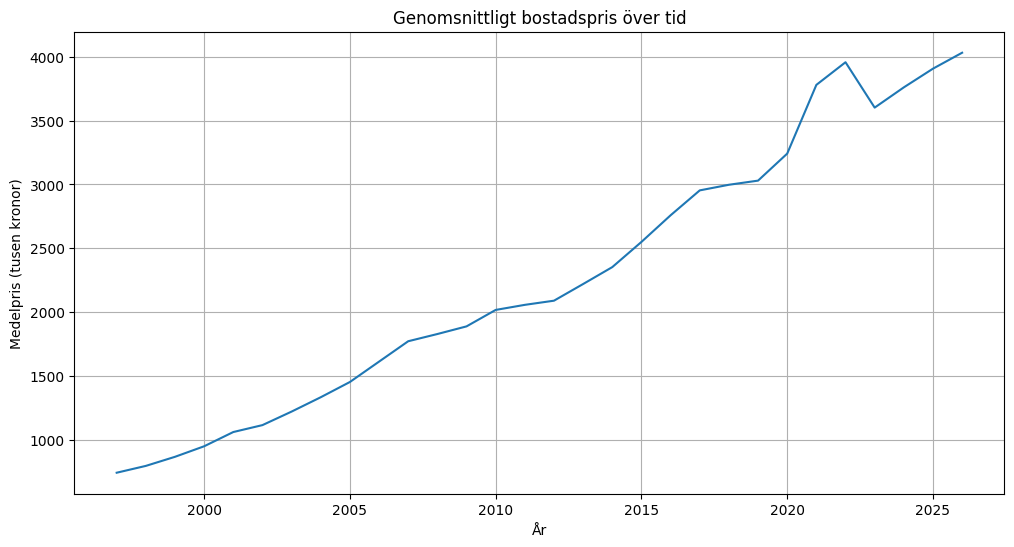

In [ ]:
# Linjediagram över bostadsprisernas utveckling

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(
    arsstatistik["År"],
    arsstatistik["Genomsnittligt medelpris"]
)

plt.title("Genomsnittligt bostadspris över tid")
plt.xlabel("År")
plt.ylabel("Medelpris (tusen kronor)")
plt.grid(True)

plt.show()

## Tolkning av diagrammet

Diagrammet visar utvecklingen av det genomsnittliga bostadspriset över tid.

Kurvan visar en tydlig långsiktig ökning av bostadspriserna under den analyserade perioden. Samtidigt varierar utvecklingen mellan olika perioder, vilket visar att prisökningen inte varit helt jämn över tid.

Visualiseringen gör det lättare att se den övergripande trenden än när resultaten endast presenteras som siffror i en tabell.

## Regional jämförelse

I detta steg jämförs bostadspriserna mellan de olika regionerna i Sverige. Analysen fokuserar på både prisnivåer och procentuell förändring under den analyserade perioden.


In [ ]:
regional_query = {
    "selection": [
        {
            "variableCode": "Region",
            "valueCodes": ["*"]
        },
        {
            "variableCode": "ContentsCode",
            "valueCodes": ["BO0501AJ"]
        },
        {
            "variableCode": "Tid",
            "valueCodes": ["*"]
        }
    ]
}

try:
    response = requests.post(
        data_url,
        json=regional_query,
        params={"outputFormat": "json-stat2"},
        timeout=30
    )

    response.raise_for_status()
    regional_data = response.json()

    print("Regional bostadsdata har hämtats från SCB!")

except requests.exceptions.RequestException as error:
    print("Ett fel uppstod vid hämtning av regional data:", error)

print("Antal värden:", len(regional_data["value"]))

Regional bostadsdata har hämtats från SCB!
Antal värden: 8825


In [ ]:
print("Dimensioner:")
print(regional_data["id"])

print("\nStorlek:")
print(regional_data["size"])

Dimensioner:
['Region', 'ContentsCode', 'Tid']

Storlek:
[25, 1, 353]


In [ ]:
regioner = list(
    regional_data["dimension"]["Region"]["category"]["label"].values()
)

tider = list(
    regional_data["dimension"]["Tid"]["category"]["label"].values()
)

regional_prices = pd.DataFrame({
    "Region": np.repeat(regioner, len(tider)),
    "Tid": tider * len(regioner),
    "Medelpris": regional_data["value"]
})

regional_prices.head()

,Region,Tid,Medelpris
0,Riket,1997M04,731
1,Riket,1997M05,739
2,Riket,1997M06,748
3,Riket,1997M07,752
4,Riket,1997M08,758


In [ ]:
print("Antal regioner:", regional_prices["Region"].nunique())

print("\nRegioner:")
print(regional_prices["Region"].unique())

Antal regioner: 25

Regioner:
['Riket' 'Stor-Stockholm' 'Stor-Göteborg' 'Stor-Malmö' 'Stockholms län'
 'Uppsala län' 'Södermanlands län' 'Östergötlands län' 'Jönköpings län'
 'Kronobergs län' 'Kalmar län' 'Gotlands län' 'Blekinge län' 'Skåne län'
 'Hallands län' 'Västra Götalands län' 'Värmlands län' 'Örebro län'
 'Västmanlands län' 'Dalarnas län' 'Gävleborgs län' 'Västernorrlands län'
 'Jämtlands län' 'Västerbottens län' 'Norrbottens län']


In [ ]:
regional_prices["År"] = regional_prices["Tid"].str[:4].astype(int)

regional_prices.head()

,Region,Tid,Medelpris,År
0,Riket,1997M04,731,1997
1,Riket,1997M05,739,1997
2,Riket,1997M06,748,1997
3,Riket,1997M07,752,1997
4,Riket,1997M08,758,1997


In [ ]:
regional_statistik = (
    regional_prices
    .groupby("Region")["Medelpris"]
    .mean()
    .sort_values(ascending=False)
)

regional_statistik

,Medelpris
Region,
Stockholms län,4183.915014
Stor-Stockholm,4183.915014
Stor-Göteborg,3282.713881
Stor-Malmö,2982.152975
Hallands län,2510.906516
Uppsala län,2384.572238
Skåne län,2338.903683
Västra Götalands län,2327.674221
Riket,2257.932011


In [ ]:
regional_forandring = (
    regional_prices
    .groupby("Region")
    .agg(
        Forsta_pris=("Medelpris", "first"),
        Sista_pris=("Medelpris", "last")
    )
)

regional_forandring["Procentuell förändring"] = (
    (regional_forandring["Sista_pris"] - regional_forandring["Forsta_pris"])
    / regional_forandring["Forsta_pris"]
) * 100
regional_forandring["Procentuell förändring"] = (
    regional_forandring["Procentuell förändring"].round(2)
)

regional_forandring = regional_forandring.sort_values(
    "Procentuell förändring",
    ascending=False
)

regional_forandring

,Forsta_pris,Sista_pris,Procentuell förändring
Region,,,
Gotlands län,633,4108,548.97
Stor-Malmö,868,5424,524.88
Hallands län,718,4454,520.33
Uppsala län,701,4259,507.56
Stor-Stockholm,1192,7140,498.99
Stockholms län,1192,7140,498.99
Stor-Göteborg,958,5618,486.43
Skåne län,731,4282,485.77
Västra Götalands län,725,4129,469.52


## Resultat av den regionala analysen

Den regionala analysen visar att bostadspriserna har ökat i samtliga 25 regioner under den analyserade perioden.

När de första och sista tillgängliga observationerna jämförs varierar den procentuella förändringen mellan regionerna. tex Riket(alla städer) hade en förändring på cirka 453,49 %, medan Gotlands län hade 548,97 % och Kalmar län 323,42 %.

Resultaten visar därmed att prisutvecklingen inte varit lika stor i alla regioner. Det finns regionala skillnader både i de genomsnittliga prisnivåerna och i hur mycket priserna har förändrats över perioden.

Det är viktigt att notera att jämförelsen baseras på den första och sista tillgängliga perioden i SCB:s dataset och därför inte ska tolkas som en jämförelse mellan två kompletta kalenderår.


## BostadsAnalys och RegionalAnalys

I detta steg används objektorienterad programmering (OOP) för att strukturera bostadsanalysen med hjälp av klasser och arv.

En basklass `BostadsAnalys` skapas för generell analys, medan `RegionalAnalys` ärver från basklassen och används för regional analys.


In [ ]:
class BostadsAnalys:
    def __init__(self, data):
        self.data = data

    def visa_info(self):
        print("Antal observationer:", len(self.data))
        print("Kolumner:", self.data.columns.tolist())
analys = BostadsAnalys(regional_prices)

analys.visa_info()

Antal observationer: 8825
Kolumner: ['Region', 'Tid', 'Medelpris', 'År']


In [60]:
class RegionalAnalys(BostadsAnalys):

    def visa_regioner(self):
        regioner = self.data["Region"].unique()
        print("Antal regioner:", len(regioner))
        print("Regioner:", regioner)

    def genomsnitt_per_region(self):
        resultat = (
            self.data
            .groupby("Region")["Medelpris"]
            .mean()
            .sort_values(ascending=False)
        )

        return resultat

    def analysera_region(self, region):
        resultat = self.data[self.data["Region"] == region]

        if resultat.empty:
            print("Regionen finns inte i datasetet.")
            return

        print("Region:", region)
        print("Antal observationer:", len(resultat))
        print(
            "Genomsnittligt medelpris:",
            round(resultat["Medelpris"].mean(), 2)
        )

In [ ]:
analys = BostadsAnalys(regional_prices)

regional_analys = RegionalAnalys(regional_prices)

regional_analys.visa_info()

regional_analys.visa_regioner()

pris_per_region = regional_analys.genomsnitt_per_region()

pris_per_region

regional_analys.analysera_region("Uppsala län")






## Resultat av OOP-analysen

Den objektorienterade delen av projektet fungerar som planerat. Basklassen `BostadsAnalys` innehåller generell funktionalitet för bostadsdata, medan `RegionalAnalys` ärver från basklassen och innehåller metoder för regional analys.

Med hjälp av klasserna kan vi bland annat visa information om datasetet, identifiera regioner och beräkna genomsnittliga bostadspriser per region. OOP-strukturen gör koden mer organiserad och gör det enklare att bygga vidare på projektet med fler analysmetoder.


## Interaktiv regional analys

I detta steg utökas projektet med en interaktiv meny där användaren kan välja en region och få information om bostadspriserna för den valda regionen.


In [69]:
def valj_region(data):
    regioner = data["Region"].unique()

    print("Välj en region:")

    for nummer, region in enumerate(regioner, start=1):
        print(f"{nummer}. {region}")

    try:
        val = int(input("Ange nummer: "))

        if 1 <= val <= len(regioner):
            return regioner[val - 1]
        else:
            print("Ogiltigt val.")
            return None

    except ValueError:
        print("Du måste ange ett nummer.")
        return None

In [79]:
vald_region = valj_region(regional_prices)

if vald_region is not None:
    regional_analys.analysera_region(vald_region)

Välj en region:
1. Riket
2. Stor-Stockholm
3. Stor-Göteborg
4. Stor-Malmö
5. Stockholms län
6. Uppsala län
7. Södermanlands län
8. Östergötlands län
9. Jönköpings län
10. Kronobergs län
11. Kalmar län
12. Gotlands län
13. Blekinge län
14. Skåne län
15. Hallands län
16. Västra Götalands län
17. Värmlands län
18. Örebro län
19. Västmanlands län
20. Dalarnas län
21. Gävleborgs län
22. Västernorrlands län
23. Jämtlands län
24. Västerbottens län
25. Norrbottens län
Ange nummer: 26
Ogiltigt val.


## Resultat av den interaktiva regionala analysen

Den interaktiva funktionen gör det möjligt för användaren att välja en region genom en meny och därefter analysera den valda regionens bostadspriser.

Funktionen använder loopar för att visa regionerna, villkor för att kontrollera användarens val och `try/except` för att hantera felaktig inmatning. Den valda regionen skickas sedan till `RegionalAnalys`, där information om antal observationer och genomsnittligt medelpris visas.

Detta gör projektet mer användarvänligt och visar hur funktioner, felhantering och objektorienterad programmering kan kombineras i ett praktiskt användningsområde.
